<a href="https://colab.research.google.com/github/TateKessler/Tate-Kessler-Github/blob/main/Kessler_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Categorical Columns: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
                         mean     median           std
price            4.766729e+06  4340000.0  1.870440e+06
area             5.150541e+03     4600.0  2.170141e+03
bedrooms         2.965138e+00        3.0  7.380639e-01
bathrooms        1.286239e+00        1.0  5.024696e-01
stories          1.805505e+00        2.0  8.674925e-01
mainroad         8.587156e-01        1.0  3.486347e-01
guestroom        1.779817e-01        0.0  3.828487e-01
basement         3.504587e-01        0.0  4.775519e-01
hotwaterheating  4.587156e-02        0.0  2.093987e-01
airconditioning  3.155963e-01        0.0  4.651799e-01
parking          6.935780e-01        0.0  8.615858e-01
prefarea         2.348624e-01        0.0  4.243022e-01


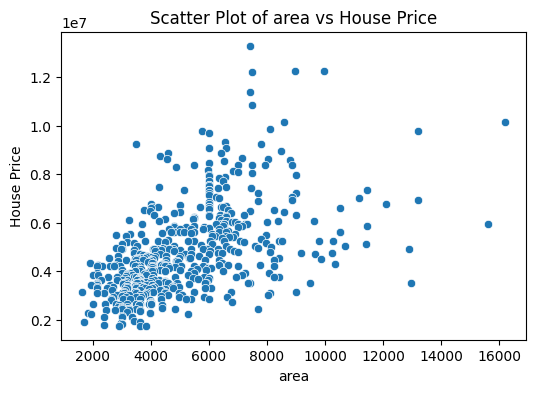

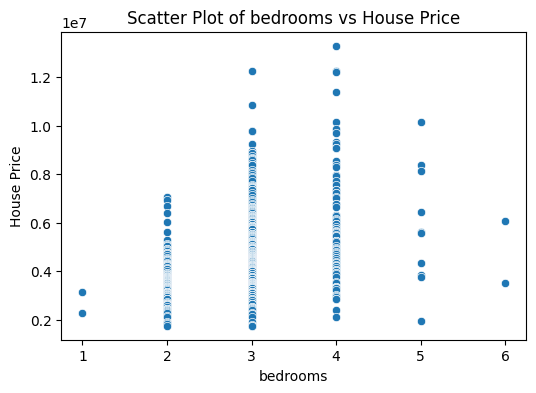

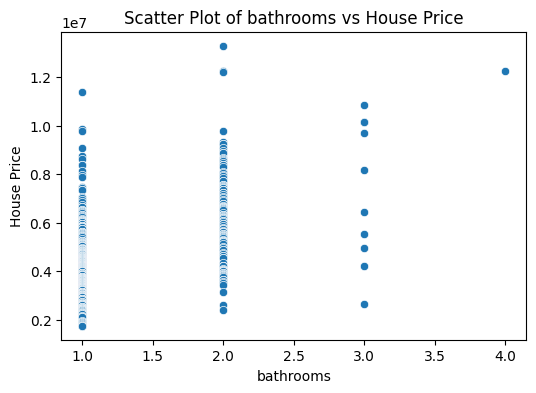

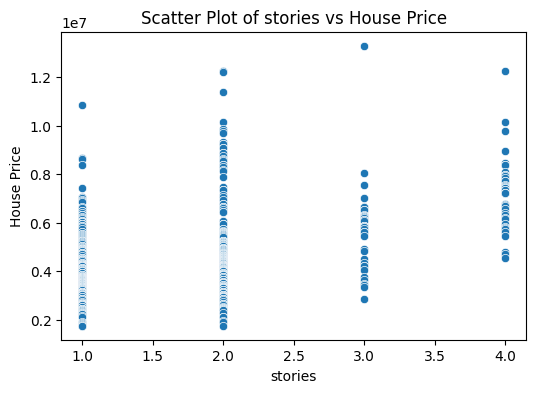

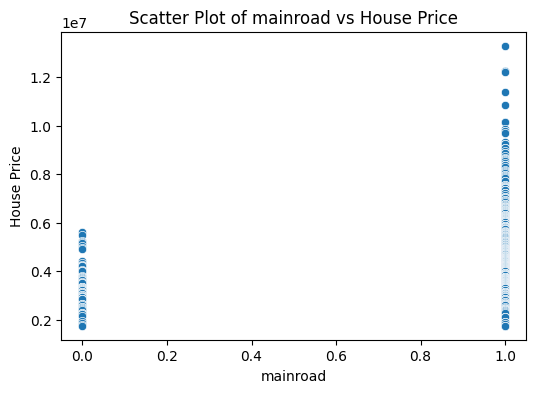

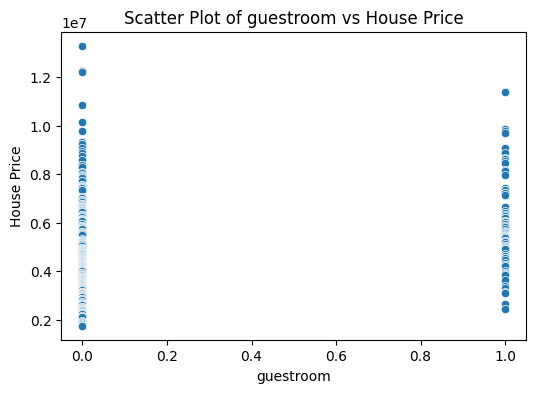

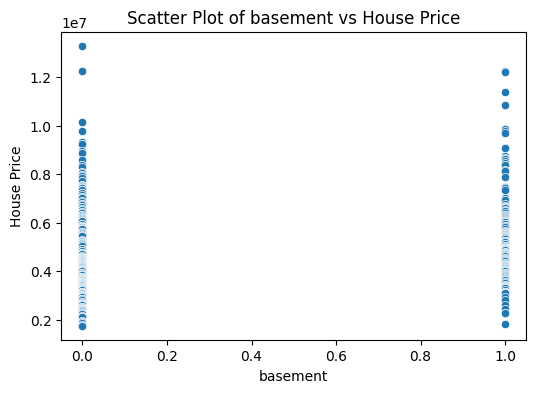

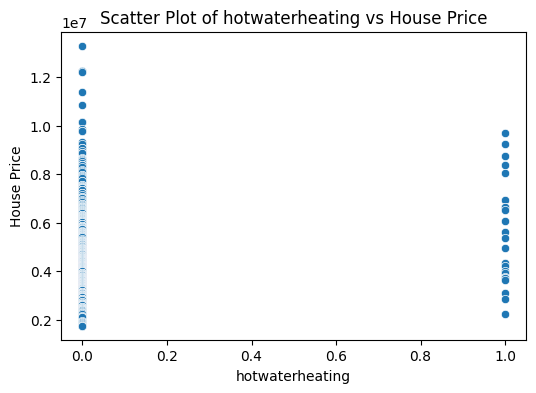

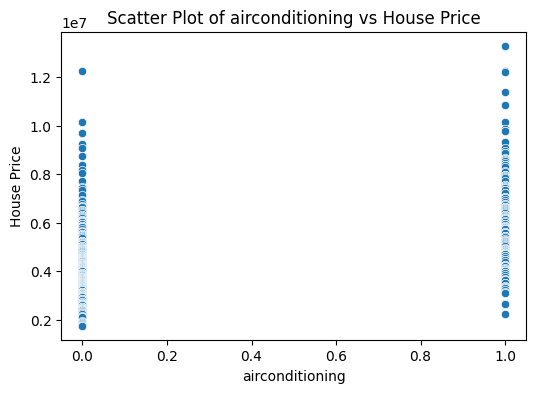

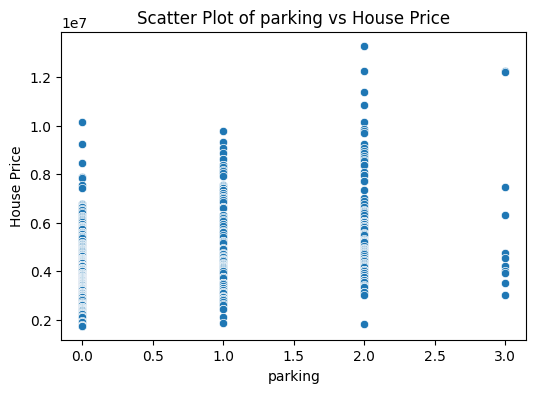

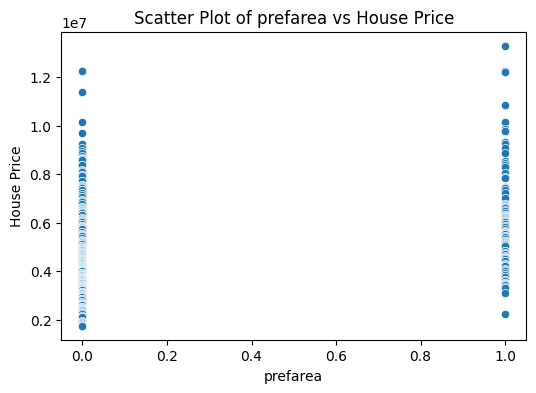

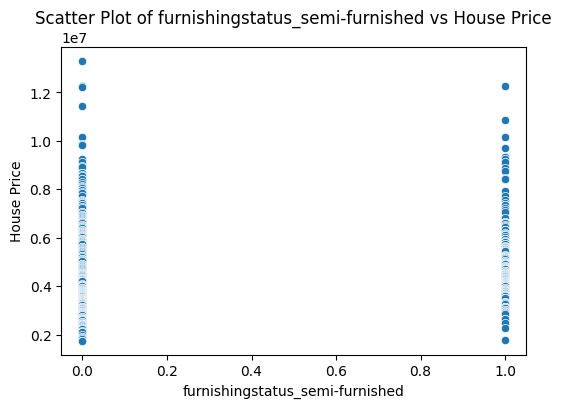

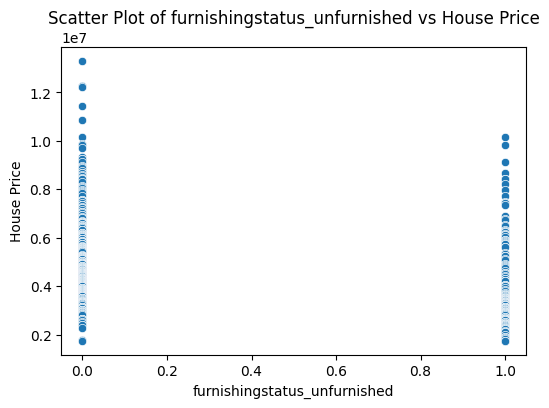

The scatter plots show the relationship between various independent variables and house price. We observe that some variables, such as area, appear to have a strong positive correlation with house price, while categorical variables like main road presence show distinct clusters. Outliers are also visible in some cases, which may influence regression analysis later.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "HW2.csv"
data = pd.read_csv(file_path)

categorical_cols = data.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in data.columns:
        data[col] = data[col].map({'yes': 1, 'no': 0})

if 'furnishingstatus' in data.columns:
    data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

stats_summary = data.describe().T
stats_summary["median"] = data.median()
stats_summary = stats_summary[["mean", "median", "std"]]
print(stats_summary)

house_price_col = "price"
independent_vars = [col for col in data.columns if col != house_price_col]

for var in independent_vars:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=data[var], y=data[house_price_col])
    plt.xlabel(var)
    plt.ylabel("House Price")
    plt.title(f"Scatter Plot of {var} vs House Price")
    plt.show()

interpretation = "The scatter plots show the relationship between various independent variables and house price. We observe that some variables, such as area, appear to have a strong positive correlation with house price, while categorical variables like main road presence show distinct clusters. Outliers are also visible in some cases, which may influence regression analysis later."
print(interpretation)


In [8]:
import pandas as pd
from scipy.stats import pearsonr

correlations = {}
for var in independent_vars:
    corr, _ = pearsonr(data[var], data[house_price_col])
    correlations[var] = corr

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Variable', 'Correlation'])
correlation_df = correlation_df.sort_values(by='Correlation', ascending=False)
print(correlation_df)

best_var = correlation_df.iloc[0]['Variable']
print(f"Variable with strongest correlation: {best_var}")

correlation_interpretation = f"The variable {best_var} has the strongest correlation with house price. This suggests that changes in {best_var} are highly associated with changes in house price. A higher absolute correlation value indicates a stronger linear relationship between the variables."
print(correlation_interpretation)


                           Variable  Correlation
0                              area     0.535997
2                         bathrooms     0.517545
8                   airconditioning     0.452954
3                           stories     0.420712
9                           parking     0.384394
1                          bedrooms     0.366494
10                         prefarea     0.329777
4                          mainroad     0.296898
5                         guestroom     0.255517
6                          basement     0.187057
7                   hotwaterheating     0.093073
11  furnishingstatus_semi-furnished     0.063656
12     furnishingstatus_unfurnished    -0.280587
Variable with strongest correlation: area
The variable area has the strongest correlation with house price. This suggests that changes in area are highly associated with changes in house price. A higher absolute correlation value indicates a stronger linear relationship between the variables.


R-squared Value: 0.2872931546811469


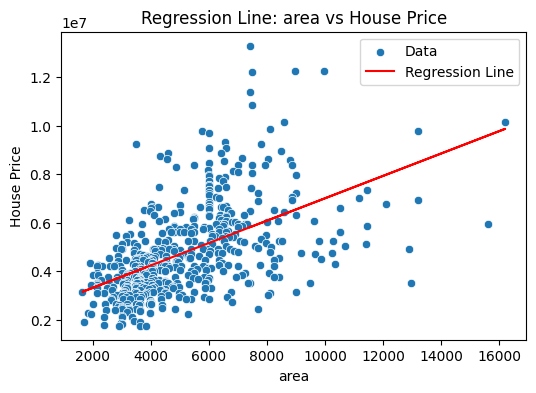

Slope: 461.97489427278344, Intercept: 2387308.48239643
Interpretation: A one-unit increase in area leads to an increase of 461.97489427278344 in house price, holding other factors constant.


In [10]:
X = data[[best_var]].values.reshape(-1, 1)
y = data[house_price_col].values.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r_squared = r2_score(y, y_pred)
print(f"R-squared Value: {r_squared}")

plt.figure(figsize=(6, 4))
sns.scatterplot(x=data[best_var], y=data[house_price_col], label='Data')
plt.plot(data[best_var], y_pred, color='red', label='Regression Line')
plt.xlabel(best_var)
plt.ylabel('House Price')
plt.title(f'Regression Line: {best_var} vs House Price')
plt.legend()
plt.show()

slope = model.coef_[0][0]
intercept = model.intercept_[0]
print(f"Slope: {slope}, Intercept: {intercept}")
print(f"Interpretation: A one-unit increase in {best_var} leads to an increase of {slope} in house price, holding other factors constant.")


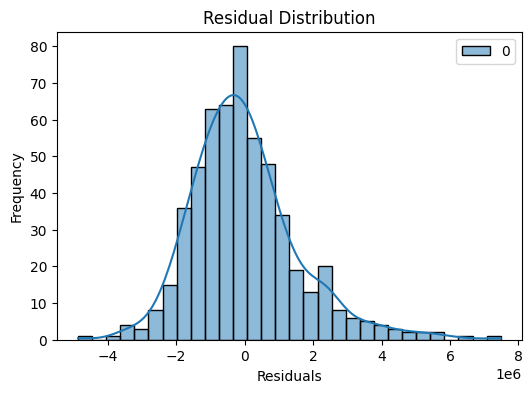

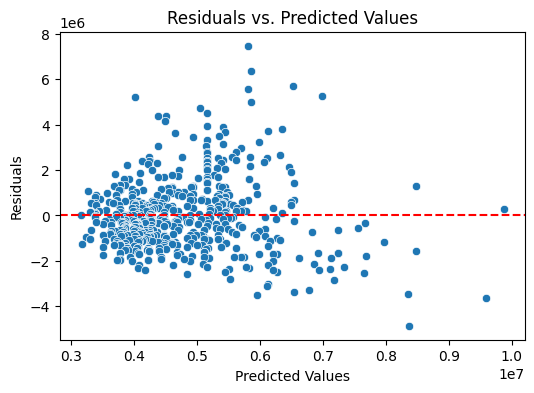

If the residuals are randomly scattered around zero with no clear pattern, it suggests that the model's assumptions hold. However, if patterns exist, such as a funnel shape or curvature, it may indicate heteroscedasticity or non-linearity in the relationship between the variables.


In [11]:
residuals = y - y_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred.flatten(), y=residuals.flatten())
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.show()

residual_interpretation = "If the residuals are randomly scattered around zero with no clear pattern, it suggests that the model's assumptions hold. However, if patterns exist, such as a funnel shape or curvature, it may indicate heteroscedasticity or non-linearity in the relationship between the variables."
print(residual_interpretation)


In [13]:
# Part 5: Linear Regression - All IVs
X_all = data[independent_vars]
model_all = LinearRegression()
model_all.fit(X_all, y)
y_pred_all = model_all.predict(X_all)

# Calculate R-squared value for multiple regression
r_squared_all = r2_score(y, y_pred_all)
print(f"R-squared Value for Multiple Regression: {r_squared_all}")
print(f"Comparison: Single IV R-squared = {r_squared}, Multiple IVs R-squared = {r_squared_all}")

# Interpretation of coefficients
coefficients = pd.DataFrame({'Variable': independent_vars, 'Coefficient': model_all.coef_.flatten()})
print(coefficients)

from sklearn.model_selection import cross_val_score  # Ensure it's imported here

# Part 6: k-Fold Cross-Validation (k=5)
k = 5
cv_scores = cross_val_score(model, X, y.ravel(), cv=k, scoring='r2')  # Ensure y is 1D
print(f"Cross-Validation R-squared Scores: {cv_scores}")
print(f"Mean R-squared from Cross-Validation: {np.mean(cv_scores)}")


R-squared Value for Multiple Regression: 0.6818018485540142
Comparison: Single IV R-squared = 0.2872931546811469, Multiple IVs R-squared = 0.6818018485540142
                           Variable    Coefficient
0                              area     244.139386
1                          bedrooms  114787.560185
2                         bathrooms  987668.107286
3                           stories  450848.002859
4                          mainroad  421272.588726
5                         guestroom  300525.859636
6                          basement  350106.904136
7                   hotwaterheating  855447.145397
8                   airconditioning  864958.311317
9                           parking  277107.101342
10                         prefarea  651543.799863
11  furnishingstatus_semi-furnished  -46344.619980
12     furnishingstatus_unfurnished -411234.386157
Cross-Validation R-squared Scores: [ -4.48747915  -8.93725564 -15.94730772 -35.66059689 -22.62706961]
Mean R-squared from Cross-